28.01.2026

## A/B-тестирование алгоритма рекомендаций

Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

# Описание данных

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


Что нужно сделать:
- рассчитать параметры теста,
- оценить корректность его проведения,
- проанализировать результаты эксперимента.

##  Работа с историческими данными (EDA)

###  Загрузка исторических данных
- Импортируйте библиотеку pandas.
- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.
- Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# загружаем исторические данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
#выводим первые 5 строк датафрейма
display(sessions_history.head())

#выводим общую информацию по датафрейму
sessions_history.info()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


### Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# рассчитайте количество уникальных сессий
unique_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
# Находим пользователя с максимальным количеством сессий
user_id_max_sessions = unique_sessions.idxmax()

# Выгружаем все данные для пользователя с максимальным количеством сессий
data_user_max_sessions = sessions_history.loc[sessions_history['user_id'] == user_id_max_sessions]
display(data_user_max_sessions)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [5]:
#Агрегируем исторические данные
history_registration =(sessions_history.groupby('session_date')
                       .agg(total_uniq_users=('user_id', 'nunique'), 
                        registration_of_users=('registration_flag', 'sum')).reset_index())
display(history_registration.head())

,session_date,total_uniq_users,registration_of_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840


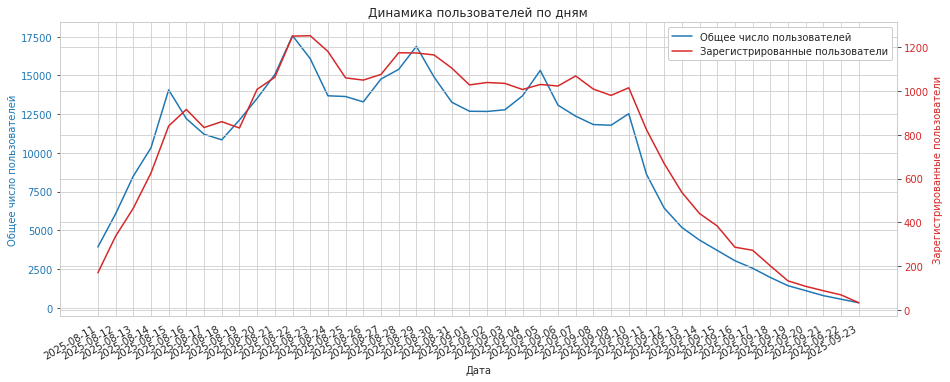

In [6]:
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(15, 6))

# Строим график для общего числа пользователей
color = 'tab:blue'
ax1.set_xlabel('Дата')
ax1.set_ylabel('Общее число пользователей', color=color)
sns.lineplot(x='session_date', y='total_uniq_users', data=history_registration, label='Общее число пользователей', color=color, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)

# Создаем вторую ось Y для зарегистрированных пользователей
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Зарегистрированные пользователи', color=color)  # добавляем метку для второй оси
sns.lineplot(x='session_date', y='registration_of_users', data=history_registration, label='Зарегистрированные пользователи', color=color, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Динамика пользователей по дням')

# Отображаем легенду
lines_ax1 = ax1.get_lines()
lines_ax2 = ax2.get_lines()

lines = lines_ax1 + lines_ax2
labels = [line.get_label() for line in lines]

plt.legend(lines, labels, loc='upper right', framealpha=1)

# Устанавливаем угол наклона меток по оси X
ax1.xaxis.set_tick_params(rotation=45)
ax1.figure.autofmt_xdate()

plt.show()


**<p style="color: black; background-color: orange;">Вывод</p>**
- `Количество пользователей` в период 14.08.2025 по 09.09.2025 остается примерно на одном уровне, за исключением выбросов на 3000-4000 количества пользователей, которое происходит каждый четверг.
- Для `количества зарегистрированных пользователей` наблюдается похожая тенденция. 
- Количество пользователей примерно постоянно до 10.09.2025.
- После 10.09.2025 происходит резкое снижение и отток пользователей.

,session_date,total_uniq_users,registration_of_users,registration_ratio
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


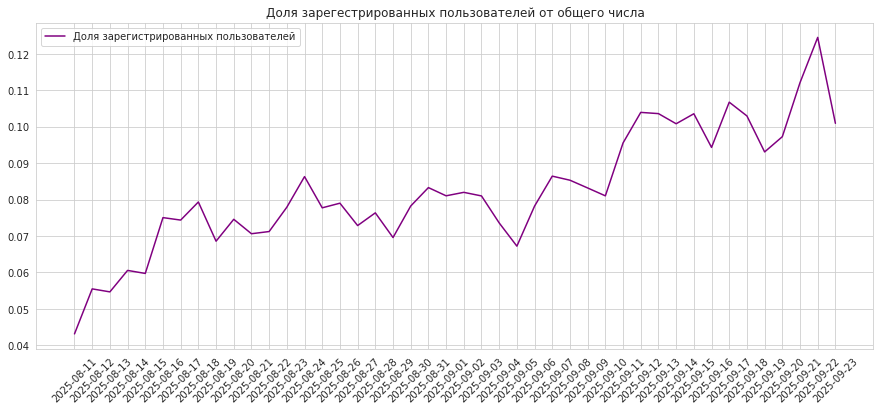

In [7]:
#добавим долю зарегистрированных пользователей от всех пользователей в прошлую таблицу:
history_registration['registration_ratio'] = history_registration['registration_of_users'] / history_registration['total_uniq_users']
display(history_registration.head())

#Постром график доли зарегистрированных пользователей от всех пользователей по дням:
plt.figure(figsize=(15, 6))
plt.plot(history_registration['session_date'], history_registration['registration_ratio'], label='Доля зарегистрированных пользователей', color = 'purple')
plt.title('Доля зарегестрированных пользователей от общего числа') 
plt.xlabel('')
plt.ylabel('')
plt.legend() 
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**<p style="color: black; background-color: orange;">Вывод</p>**
- наблюдается рост доли зарегистрированных пользователей.
- до 17.08.2025 происходит рост до уровня 8%;
- с 17.08.2025 по 09.09.2025 показатель в среднем держится на одном уровне 7-8,5%; 
- после 09.09.2025 наблюдется резкий рост доли зарегистрированных пользователей до 12,5%. 

Используя данные из графика `Динамика пользователей по дням` можно сделать вывод, что рост доли зарегистрированных пользователей в первую очеред связан со снижением общего числа пользователей. Рост доли зарегистрированных пользователей отражает, что скорость оттока пользователей в целом выше, чем скорость с который зарегестрированные пользователи перестают пользоваться сервисом.

### Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. 
- Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

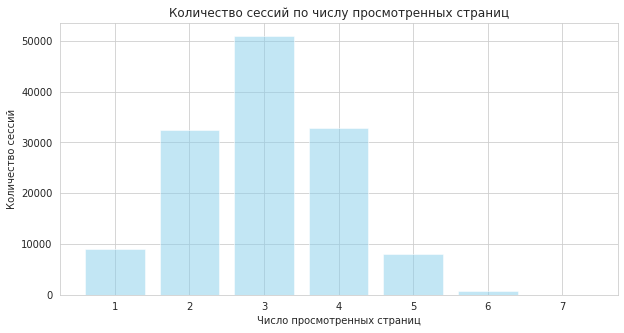

In [8]:
# Группируем по количеству просмотренных страниц и считаем количество сессий
first_sessions = sessions_history[sessions_history['session_number'] == 1]
page_count = first_sessions['page_counter'].value_counts().sort_index().reset_index()
page_count.columns = ['page_counter', 'count']

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
plt.bar(page_count['page_counter'], page_count['count'], color='skyblue', alpha=0.5)

# Добавляем заголовки и метки осей
plt.title('Количество сессий по числу просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()


**<p style="color: black; background-color: orange;">Вывод</p>**
- Данное распределение похоже на нормальное распределение с правым хвостом. 
- Количество просмотренных страниц нормально распределено вокруг значения 3 (страницы).

### Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [9]:
def def_good_session(page_count):
    if page_count >= 4:
        return 1
    else:
        return 0

sessions_history['good_session'] = sessions_history['page_counter'].apply(def_good_session)

In [10]:
# Отфильтровываем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Агрегируем, чтобы получить средние значения доли успешных сессий от всех первых сессий пользователей.
df_daily_success_rate = (first_sessions.groupby('session_date')
                          .agg(daily_success_rate=('good_session', 'mean'))
                          .reset_index())

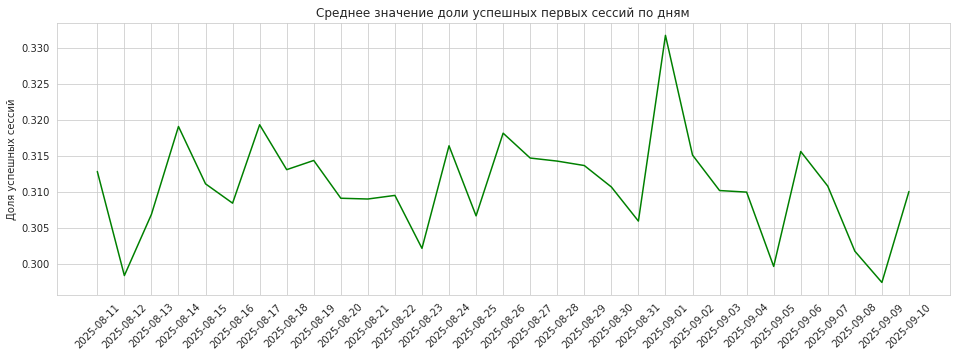

In [11]:
# Построение графика
plt.figure(figsize=(16, 5))
plt.plot(df_daily_success_rate['session_date'], df_daily_success_rate['daily_success_rate'], color = 'green')
plt.title('Среднее значение доли успешных первых сессий по дням')
plt.xlabel('')
plt.ylabel('Доля успешных сессий')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**<p style="color: black; background-color: orange;">Вывод</p>**

- На всем интервале доля успешных сессий держится в на уровне 0.3 - 0.32
- есть небольшой выброс 31.08.2025, когда доля успешных сессий превысила 0.33. Других выбросов нет.



## Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

### Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [12]:

# Задайте параметры: 
alpha = 0.05 # Уровень значимости 
beta = 0.2 # Ошибка второго рода, часто 1 - мощность 
power = 1-beta # Мощность теста 
p1 = 0.3 # Базовый уровень доли 
mde = 0.03*p1 # Минимальный детектируемый эффект 
effect_size = proportion_effectsize(p1, p1 + mde)
print(effect_size)

-0.0195573929997348


In [13]:

# Инициализируем класс NormalIndPower 
power_analysis = NormalIndPower()
# Расчёт размера выборки 
sample_size = power_analysis.solve_power( 
    effect_size = effect_size, 
    power = power, 
    alpha = alpha, 
    ratio = 1 # Равномерное распределение выборок 
)
print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


### Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [14]:

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = (sessions_history.groupby('session_date')['user_id'].nunique().mean())
#учитываем, что трафик делится между двумя группами:
daily_users_per_group = avg_daily_users / 2

# Рассчитываем длительность теста
test_duration = ceil(sample_size/daily_users_per_group)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {round(avg_daily_users)} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


**<p style="color: black; background-color: orange;">Вывод</p>**
- Необходимый размер выборки для 2 групп тестирования составляет 82 080 (41 040 для одной группы)
- Рассчитанная длительность A/B-теста при текущем уровене трафика в 9 907 пользователей в день составит 9 дней


## Мониторинг А/В-теста

#### Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [15]:
#сохраним информацию из sessions_project_test_part.csv в новый датафрейм:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [16]:
#Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения
test_groups = (sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index())
test_groups

,test_group,user_id
0,A,1477
1,B,1466


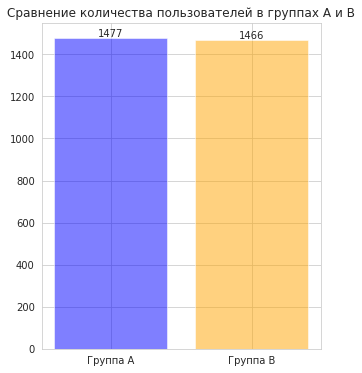

Процентная разница в количестве пользователей: 0.74%


In [17]:
a_group = test_groups[test_groups['test_group'] == 'A']['user_id'].values[0]
b_group = test_groups[test_groups['test_group'] == 'B']['user_id'].values[0]

# Рассчитываем процентную разницу
ratio_ab = abs(a_group - b_group) / a_group * 100


# Построение визуализации
plt.figure(figsize=(5, 6))
plt.bar(['Группа A', 'Группа B'], [a_group, b_group], color=['blue', 'orange'], alpha=0.5)

# Добавление аннотаций с количеством пользователей для каждой группы
for i, value in enumerate([a_group, b_group]):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.ylabel('')
plt.xlabel('')

plt.title('Сравнение количества пользователей в группах A и B')
plt.show()
print(f"Процентная разница в количестве пользователей: {ratio_ab:.2f}%")

### Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [18]:
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

# Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B
intersection = list(set(users_A) & set(users_B))

if intersection == []:
    print('В группах А и В нет общих пользователей')
else:
    print(f"Количество пользователей который попали в обе группы А и В: {len(intersection)}")

В группах А и В нет общих пользователей


### Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [19]:
# Группируем данные по тестовой группе и региону
device_dist = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().unstack()

# Нормализуем данные для отображения долей
device_dist_normalized = device_dist.div(device_dist.sum(axis=1), axis=0) * 100

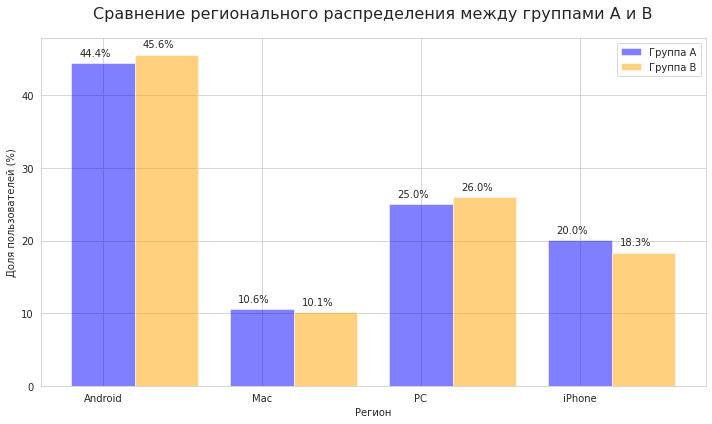

device,Android,Mac,PC,iPhone
test_group,,,,
A,44.41%,10.56%,24.98%,20.04%
B,45.57%,10.10%,25.99%,18.35%
Share Difference A-B,2.59%,-4.42%,4.03%,-8.44%


In [20]:
plt.figure(figsize=(10, 6))  

# Создаём массив позиций для столбцов
x_positions_A = np.arange(len(device_dist_normalized.columns))
x_positions_B = x_positions_A + 0.4  # Сдвигаем позиции для второй группы

plt.bar(x_positions_A, device_dist_normalized.loc['A'], color='blue', label='Группа A', alpha=0.5, width=0.4)
plt.bar(x_positions_B, device_dist_normalized.loc['B'], color='orange', label='Группа B', alpha=0.5, width=0.4)

plt.title('Сравнение регионального распределения между группами A и B', fontsize=16, pad=20)
plt.xlabel('Регион')
plt.ylabel('Доля пользователей (%)')
plt.xticks(x_positions_A, device_dist_normalized.columns)
plt.legend()
plt.grid(True)

# Добавляем значения на столбцы
for i, (a_val, b_val) in enumerate(zip(device_dist_normalized.loc['A'], device_dist_normalized.loc['B'])):
    plt.text(i - 0.05, a_val + 1, f'{a_val:.1f}%', ha='center')
    plt.text(i + 0.35, b_val + 1, f'{b_val:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Вычисляем разницу между строками 1 и 2 для каждой колонки
difference = round((device_dist_normalized.iloc[1] - device_dist_normalized.iloc[0])/device_dist_normalized.iloc[0]*100,2)

# Добавляем новую строку с разницей в таблицу
device_dist_normalized.loc['Share Difference A-B'] = difference
styled_df1 = device_dist_normalized.style.format('{:.2f}%')

display(styled_df1)

### Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [21]:
# Группируем данные по тестовой группе и региону
dist_region = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().unstack()

# Нормализуем данные для отображения долей
region_dist_normalized = dist_region.div(dist_region.sum(axis=1), axis=0) * 100

display(region_dist_normalized)

region,CIS,EU,MENA
test_group,,,
A,43.601896,15.165877,41.232227
B,43.997271,14.802183,41.200546


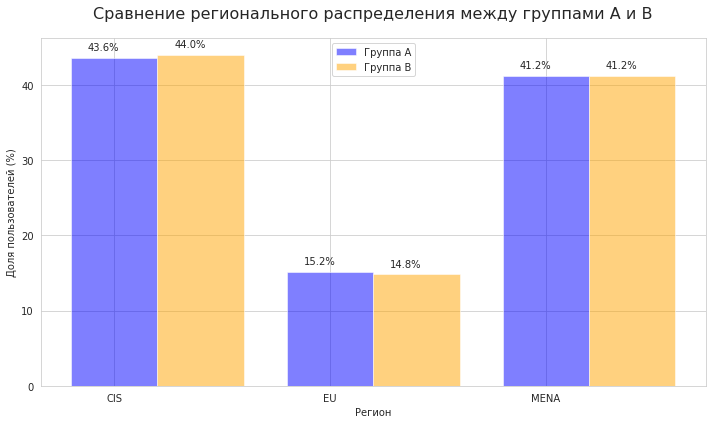

region,CIS,EU,MENA
test_group,,,
A,43.60%,15.17%,41.23%
B,44.00%,14.80%,41.20%
Share Difference A-B,0.91%,-2.40%,-0.08%


In [22]:
plt.figure(figsize=(10, 6))  

# Создаём массив позиций для столбцов
x_positions_A = np.arange(len(region_dist_normalized.columns))
x_positions_B = x_positions_A + 0.4  # Сдвигаем позиции для второй группы

plt.bar(x_positions_A, region_dist_normalized.loc['A'], color='blue', label='Группа A', alpha=0.5, width=0.4)
plt.bar(x_positions_B, region_dist_normalized.loc['B'], color='orange', label='Группа B', alpha=0.5, width=0.4)

plt.title('Сравнение регионального распределения между группами A и B', fontsize=16, pad=20)
plt.xlabel('Регион')
plt.ylabel('Доля пользователей (%)')
plt.xticks(x_positions_A, region_dist_normalized.columns)
plt.legend()
plt.grid(True)

# Добавляем значения на столбцы
for i, (a_val, b_val) in enumerate(zip(region_dist_normalized.loc['A'], region_dist_normalized.loc['B'])):
    plt.text(i - 0.05, a_val + 1, f'{a_val:.1f}%', ha='center')
    plt.text(i + 0.35, b_val + 1, f'{b_val:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Вычисляем разницу между строками 1 и 2 для каждой колонки
difference = round((region_dist_normalized.iloc[1] - region_dist_normalized.iloc[0])/region_dist_normalized.iloc[0]*100,2)

# Добавляем новую строку с разницей в таблицу
region_dist_normalized.loc['Share Difference A-B'] = difference
styled_df = region_dist_normalized.style.format('{:.2f}%')

display(styled_df)

### Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**<p style="color: black; background-color: orange;">Вывод:</p>**

- **Количество пользователей в группах:** Различие между группами A и B составляет около 0.74 % — это несущественно. По числу уникальных пользователей группы практически равны.

- **Независимость выборок:** Пересечений пользователей между тестовой и контрольной группами не обнаружено: ни один пользователь не попал сразу в обе группы. Выборки можно считать независимыми.

- **Равномерность распределения по категориям:**

  - *Тип устройств:* Для типов устройств `Android`,`Mac` и `PC` разница между тестовой и контрольной группами около 2-5%. Для `iPhone` - 8,44%.
  - *Регионы:* разница между долями пользователей по регионам в группах A и B в пределах 2,5%.

**Заключение:** После пересчёта метрик по уникальным пользователям подтверждается, что A/B-тест проводится корректно: группы сопоставимы по размеру, независимы, а распределения по устройствам и регионам с учетом небольшого объема выборки (2943) не содержат значимых перекосов. Вероятно, при дальшейшем исследовании и увеличении объёма выборки, найденные различия будут невелированы.
Нарушений, которые могли бы исказить результаты эксперимента на данном этапе, не выявлено — можно переходить к анализу ключевых метрик теста.

## Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

### Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [23]:
#сохраним информацию из sessions_project_test.csv в новый датафрейм:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

#используя функцию def_good_session, опеределенную в пункте 1.5, создадим дополнительный столбец `good_session`
sessions_test['good_session'] = sessions_test['page_counter'].apply(def_good_session)

### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

- Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

- Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Целевая метрика:** 
Используем долю первых сессий, где пользователь посмотрел 4 и больше страниц. Метрика покажет уровень заинтересованности пользователя в контенте.

**Нулевая гипотеза (H₀):** 
Использование нового алгоритма рекомендаций не влияет на долю успешных сессий (Ра=Рв).

**Альтернативная гипотеза (H₁):** 
Новый алгоритм рекомендаций увеличивает долю успешных сессий (Ра<Рв).

**Возможные прокси-материки:** 
- количество уникальный пользователей за день
- время проведенное пользоватем в приложении

**Возможные барьерные материки:**
- количество зарегестрированных пользоваталей, которые пользуются приложением ежедневно
- количество регистраций и офорлмения платных подписок

### Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [24]:
sessions_test_1st = sessions_test[sessions_test['session_number'] == 1]

#рассчитаем долю успешных первых сессий для выборок A и B
df_session = sessions_test_1st.groupby('test_group').agg(
    total_sessions=('session_id', 'count'), 
    good_sessions=('good_session', 'sum')).reset_index()

#добавим долю успешных сессий
df_session['good_session_rate'] = df_session['good_sessions'] / df_session['total_sessions']
styled_df_session = df_session.style.format({'good_session_rate': '{:.3f}'})
display(styled_df_session)

#рассчитаем разницу в долях между группами A и B
a_group = df_session[df_session['test_group'] == 'A']['good_session_rate'].values[0]
b_group = df_session[df_session['test_group'] == 'B']['good_session_rate'].values[0]

dist=b_group-a_group
share_dist=(b_group-a_group)/a_group

print(f'Разница в доле успешных сессий между группами A и B: {round(dist, 3)} или {round(share_dist * 100, 2)}%')

,test_group,total_sessions,good_sessions,good_session_rate
0,A,15162,4787,0.316
1,B,15416,4851,0.315


Разница в доле успешных сессий между группами A и B: -0.001 или -0.33%


### Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [25]:


#берём количество успехов (good_session=1) и общее количество сессий в каждой группе
metrika1 = [df_session.loc[df_session.test_group=='B', 'good_sessions'].values[0],
             df_session.loc[df_session.test_group=='A', 'good_sessions'].values[0]]
metrika2 = [df_session.loc[df_session.test_group=='B', 'total_sessions'].values[0],
          df_session.loc[df_session.test_group=='A', 'total_sessions'].values[0]]
alpha = 0.05

#применяем Z-тест пропорций
stat, p_value = proportions_ztest(metrika1, metrika2, alternative='larger')
print(f'p-value = {round(p_value,7)}')

p-value = 0.5783524


In [26]:
if p_value < alpha:
    print('Нулевая гипотеза отвергается: разница статистически значима.')
else:
    print('Нулевая гипотеза не отвергается: разница статистически не значима.')

Нулевая гипотеза не отвергается: разница статистически не значима.


### Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**<p style="color: black; background-color: orange;">Вывод по результатам A/B-теста:</p>**

Характеристики эксперимента: 
- Минимальный расчетный размер выборки для A/B теста составил 84 080 сессий. 
- Расчетная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день соствила 9 дней.
- Эксперимент проводился на двух группах пользователей — A (контрольная) и B (тестовая). 
- Всего было проанализировано 100 005 сессий. 
- Длительность теста составила 19 дней. 

Цели и задачи эксперимента, ключевая метрика: 
- Ключевая метрика — доля успешных первых сессий (4 и более просмотренные страницы)
- Нулевая гипотеза (H₀): Использование нового алгоритма рекомендаций не влияет на долю успешных первых сессий (Ра=Рв).
- Альтернативная гипотеза (H₁): Новый алгоритм рекомендаций увеличивает долю успешных первых сессий (Ра<Рв).
- Прокси-материки и барьерные материки не применялись

Результаты эксперимента
- В группе A доля успешных сессий составила 0.316, а в группе B — 0.315. 
- Разница между группами составила -0.001 или -0.33%, то есть в группе B произошло снижение по сравнению с группой А.

Статистическая значимость: 
- Z-тест показал p-value ≈ 0.578

Поскольку p-value > alpha (alpha = 0.05), то нулевая гипотеза не отвергается: разница статистически не значима.

**На основании проведенного эксперемента нельзя однозначно сделать вывод, что новый алгоритм рекомендаций как-то влияет на изменение доли успешных сессий. Рекомендуется провести новый эксперимент, увеличив срок проведения эксперимента или изменить ключевую метрику.**